In [1]:
import sounddevice as sd
import numpy as np
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import matplotlib.pyplot as plt
import librosa
import mido
import time

print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [2]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [3]:
sharc = Sharc(arthur_96, ad)


Using output: USB2.0-MIDI 1
Using input:  USB2.0-MIDI 0


In [4]:
def play_tone(freq, amp):
    sharc.pure_tone(freq, amp)

    time.sleep(0.1)

    silent = np.zeros(fs * 1, dtype=np.float32)

    error, ref = ad.play(left=silent, right=silent)

    sharc.stop_tone()

    return error, ref

In [19]:
sharc.no_cancel(1)

In [24]:
sharc.pure_tone(1000, 0.2)

In [25]:
sharc.stop_tone()

In [27]:
freqs = [300, 500, 700, 1000, 2000]
amps = [0.01, 0.02, 0.05, 0.10]

In [31]:
results = []
for freq in freqs:
    for amp in amps:
        sharc.pure_tone(freq, amp)

        time.sleep(0.1)

        silent = np.zeros(fs * 1, dtype=np.float32)

        error, ref = ad.play(left=silent, right=silent)

        sharc.stop_tone()

        error_amp, phase_rad = sharc.tone_response(error, freq, fs)

        results.append({
            "freq": freq,
            "amp": amp,
            "error_amp": error_amp,
            "gain": error_amp / amp,
            "phase": phase_rad
        })

In [34]:
import pandas as pd

df = pd.DataFrame(results)

df["gain_db"] = 20 * np.log10(df["gain"])
df["phase_deg"] = np.rad2deg(df["phase"])

df

,freq,amp,error_amp,gain,phase,gain_db,phase_deg
0,300,0.01,0.004479,0.447892,1.133844,-6.976532,64.964457
1,300,0.02,0.008337,0.416830,1.630211,-7.600826,93.404215
2,300,0.05,0.020767,0.415338,1.356657,-7.631975,77.730720
3,300,0.10,0.040783,0.407828,-1.608439,-7.790461,-92.156751
4,500,0.01,0.004410,0.441014,-0.632875,-7.110956,-36.261050
5,500,0.02,0.008920,0.445986,-2.172939,-7.013576,-124.500214
6,500,0.05,0.022392,0.447840,0.475473,-6.977549,27.242617
7,500,0.10,0.044365,0.443650,1.030870,-7.059195,59.064475
8,700,0.01,0.004035,0.403543,0.816401,-7.882200,46.776334
9,700,0.02,0.008163,0.408148,1.645444,-7.783643,94.277024


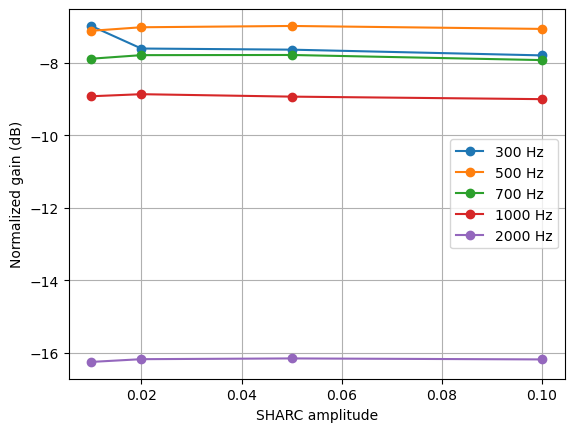

In [35]:
for freq in freqs:
    d = df[df["freq"] == freq]

    plt.plot(
        d["amp"],
        d["gain_db"],
        marker="o",
        label=f"{freq} Hz",
    )

plt.xlabel("SHARC amplitude")
plt.ylabel("Normalized gain (dB)")
plt.grid()
plt.legend()
plt.show()

In [36]:
reference_amp = 0.05

for freq in freqs:
    mask = df["freq"] == freq

    reference_gain = df[
        mask & np.isclose(df["amp"], reference_amp)
    ]["gain"].iloc[0]

    df.loc[mask, "gain_change_db"] = (
        20 * np.log10(df.loc[mask, "gain"] / reference_gain)
    )

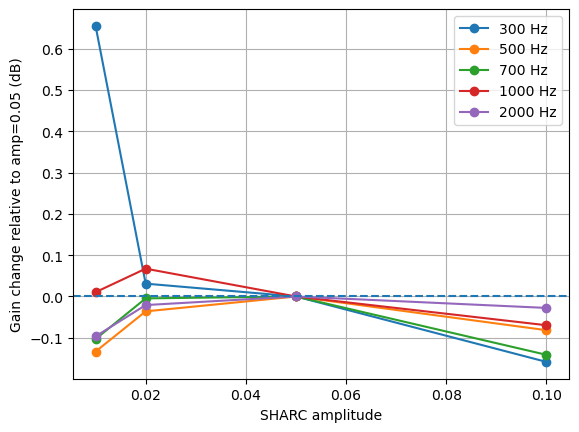

In [37]:
for freq in freqs:
    d = df[df["freq"] == freq]

    plt.plot(
        d["amp"],
        d["gain_change_db"],
        marker="o",
        label=f"{freq} Hz",
    )

plt.axhline(0, linestyle="--")
plt.xlabel("SHARC amplitude")
plt.ylabel("Gain change relative to amp=0.05 (dB)")
plt.grid()
plt.legend()
plt.show()

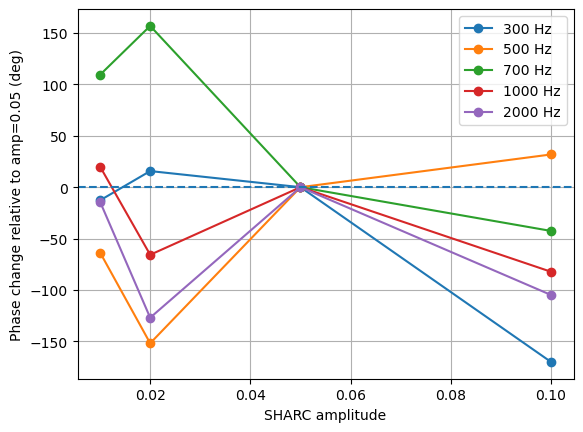

In [38]:
for freq in freqs:
    d = df[df["freq"] == freq]

    phase = np.unwrap(d["phase"].to_numpy())
    phase -= phase[np.argmin(np.abs(d["amp"].to_numpy() - reference_amp))]

    plt.plot(
        d["amp"],
        np.rad2deg(phase),
        marker="o",
        label=f"{freq} Hz",
    )

plt.axhline(0, linestyle="--")
plt.xlabel("SHARC amplitude")
plt.ylabel("Phase change relative to amp=0.05 (deg)")
plt.grid()
plt.legend()
plt.show()

In [39]:
summary = df.pivot(
    index="freq",
    columns="amp",
    values="gain_change_db",
)

print(summary.round(2))

amp   0.01  0.02  0.05  0.10
freq                        
300   0.66  0.03   0.0 -0.16
500  -0.13 -0.04   0.0 -0.08
700  -0.10 -0.00   0.0 -0.14
1000  0.01  0.07   0.0 -0.07
2000 -0.10 -0.02   0.0 -0.03


In [42]:
sharc.sharc_irs()

(array([ 1.2357860e-11,  5.0122788e-12, -5.5869628e-11, ...,
         1.2434018e-10,  1.7256717e-11,  4.0400697e-11],
       shape=(1583999,), dtype=float32),
 array([ 4.1048838e-13, -1.7067674e-12,  1.2876372e-11, ...,
         6.6434302e-12,  3.1866862e-13,  2.5304446e-12],
       shape=(1583999,), dtype=float32))

(array([ 4.63302294e-03,  4.55440348e-03,  4.35544504e-03,  4.25151875e-03,
         4.57277056e-03,  5.72350575e-03,  7.56220520e-03,  8.19420628e-03,
         3.69841303e-03, -9.86803696e-03, -3.30484472e-02, -6.07138798e-02,
        -8.30824748e-02, -9.03094336e-02, -7.85140470e-02, -5.30208647e-02,
        -2.52697282e-02, -4.87855449e-03,  6.28721202e-03,  1.24580571e-02,
         1.71502531e-02,  1.91489495e-02,  1.51991080e-02,  5.05641568e-03,
        -7.30725890e-03, -1.67548694e-02, -2.00831983e-02, -1.68162566e-02,
        -8.86347797e-03,  1.19039243e-04,  6.56014169e-03,  9.43127088e-03,
         1.04147336e-02,  1.09268352e-02,  9.73605644e-03,  4.76505980e-03,
        -3.05663212e-03, -9.26133431e-03, -9.78007354e-03, -4.66803042e-03,
         2.48377514e-03,  8.01039673e-03,  1.04327351e-02,  1.01967072e-02,
         8.56993720e-03,  6.85985712e-03,  5.63881965e-03,  4.23929607e-03,
         1.62911240e-03, -1.74500386e-03, -3.51345073e-03, -1.48181315e-03,
         3.9

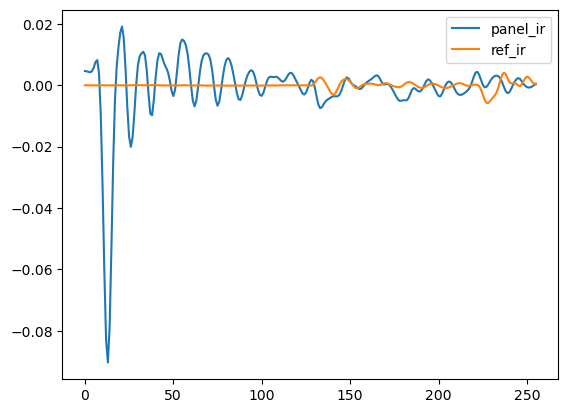

In [43]:
sharc.prep_irs()

In [46]:
error, sharc_out = play_tone(1000, 0.05)

In [47]:
amp, phase_rad = sharc.tone_response(sharc_out, 1000)
amp.item(), np.max(np.abs(sharc_out))

(0.02061987142074348, np.float32(0.023101807))

In [33]:
error, sharc_out = play_tone(1000, 0.1)

In [34]:
amp, phase_rad = sharc.tone_response(sharc_out, 1000)
amp.item()

0.04123364733546686

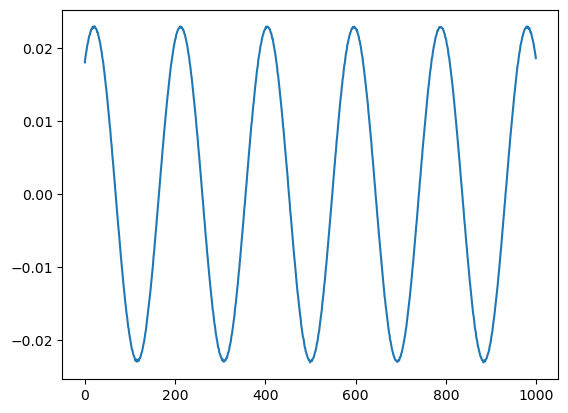

In [20]:
plt.plot(sharc_out[10000:11000])